In [1]:
import numpy as np
from matplotlib import rc,rcParams
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline 
import os
from astropy.table import Table
from scipy import stats
from astropy.cosmology import Planck18 as cosmo
import astropy.coordinates as coord

In [2]:
    def set_rc_params(fontsize=None):

        print("Setting Matplotlib RC parameters...")

        if fontsize is None:
            fontsize=16
        else:
            fontsize=int(fontsize)

        rc('font',**{'family':'serif'})
        rc('text', usetex=True)

        #plt.rcParams.update({'figure.facecolor':'w'})
        plt.rcParams.update({'axes.linewidth': 1.1})
        plt.rcParams.update({'xtick.labelsize': fontsize})
        plt.rcParams.update({'ytick.labelsize': fontsize})
        plt.rcParams.update({'xtick.major.size': 8})
        plt.rcParams.update({'xtick.major.width': 1.1})
        plt.rcParams.update({'xtick.minor.visible': True})
        plt.rcParams.update({'xtick.minor.width': 1.})
        plt.rcParams.update({'xtick.minor.size': 6})
        plt.rcParams.update({'xtick.direction': 'out'})
        plt.rcParams.update({'ytick.major.width': 1.1})
        plt.rcParams.update({'ytick.major.size': 8})
        plt.rcParams.update({'ytick.minor.visible': True})
        plt.rcParams.update({'ytick.minor.width': 1.})
        plt.rcParams.update({'ytick.minor.size':6})
        plt.rcParams.update({'ytick.direction':'out'})
        plt.rcParams.update({'axes.labelsize': fontsize})
        plt.rcParams.update({'axes.titlesize': fontsize})
        plt.rcParams.update({'legend.fontsize': int(fontsize-2)})

        return


In [3]:
set_rc_params(fontsize=16)

Setting Matplotlib RC parameters...


## Define a useful cleaning function

In [4]:
# Let's start by making color-redshift plot for redmagic
def remove_outliers(data, bands):
    # All bands are good <3
    catlen = len(data)
    wg = np.full(catlen, True)

    # Pick out only the good entries!
    for band in bands:
        band_mag = np.ma.getdata(data[band])
        band_bool = (band_mag > -9999) & (band_mag != np.nan) & (band_mag < 27)
        wg *= band_bool

    # percent of galaxies that failed
    pfail = 100-(np.count_nonzero(wg) / catlen * 100)

    # How many failed?
    print(f'RedshiftCalc: {np.count_nonzero(wg)}/{catlen} galaxies',
          f'({100-pfail:.1f}%) have good photometry')
    print(f'RedshiftCalc: removing {pfail:.1f}% of galaxies from data')
    print('')

    return wg

In [ ]:
catalog_path = '/Users/j.mccleary/Research/dusty_halos/catalogs/prep_cat_output'
hiz = Table.read(os.path.join(catalog_path, 'redmagic_hiz_y3_GOLD_JOINED_catalog.fits'))
hidens = Table.read(os.path.join(catalog_path,'redmagic_hidens_y3_GOLD_JOINED_catalog.fits'))


In [ ]:
bands = ['mof_cm_mag_corrected_g', 'mof_cm_mag_corrected_r',
        'mof_cm_mag_corrected_i', 'mof_cm_mag_corrected_z']


wg_hiz = remove_outliers(hiz, bands)
hiz = hiz[wg_hiz]
wg_hidens = remove_outliers(hidens, bands)
hidens = hidens[wg_hidens]

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12,6), tight_layout=True)
axs[0].plot(hidens['zredmagic'], 
            (hidens['mof_cm_mag_corrected_g'] - hidens['mof_cm_mag_corrected_r']), 
            '.', markersize=0.5, color='xkcd:tomato red', label='hidens')
axs[0].plot(hiz['zredmagic'], 
            (hiz['mof_cm_mag_corrected_g'] - hiz['mof_cm_mag_corrected_r']), 
             '.', markersize=0.5, color='xkcd:deep red', label='hilum_hiz')
axs[0].set_ylim(-1,6)
axs[0].legend(markerscale=15, loc='upper left')
axs[0].set_xlabel('Redshift')
axs[0].set_ylabel(r'$g$ - $r$')

axs[1].plot(hidens['zredmagic'], 
            (hidens['mof_cm_mag_corrected_i'] - hidens['mof_cm_mag_corrected_z']), 
            '.', markersize=0.5, color='xkcd:tomato red', label='hidens')
axs[1].plot(hiz['zredmagic'], 
            (hiz['mof_cm_mag_corrected_i'] - hiz['mof_cm_mag_corrected_z']), 
             '.', markersize=0.5, color='xkcd:deep red', label='hilum_hiz')
axs[1].set_ylim(-0.5,1.5)
axs[1].legend(markerscale=15, loc='upper left')
axs[1].set_xlabel('Redshift')
axs[1].set_ylabel(r'$i$ - $z$')

fig.savefig('color_redshift_redmagic.pdf')
fig.savefig('color_redshift_redmagic.png')

## OK, let's try Av histogram

In [42]:
catdir = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/'
hiz_tcatname = 'redmagic_hiz/dust_correlation_calzetti00_treecorrcat.fits'
hiz_tcatname2 = 'redmagic_hiz/dust_correlation_calzetti00_5zbins_treecorrcat.fits'
hiz_tcatname3 = 'hiz/dust_correlation_calzetti00_9zbins_treecorrcat.fits'

hiz_tcat = Table.read(os.path.join(catdir, hiz_tcatname))
hiz_tcat2 = Table.read(os.path.join(catdir, hiz_tcatname2))
hiz_tcat3 = Table.read(os.path.join(catdir, hiz_tcatname3))

hidens_tcatname = 'redmagic_hidens/dust_correlation_calzetti00_treecorrcat.fits'
hidens_tcatname2 = 'redmagic_hidens/dust_correlation_calzetti00_8zbins_treecorrcat.fits'
hidens_tcatname3 = 'redmagic_hidens/dust_correlation_calzetti00_17zbins_treecorrcat.fits'

hidens_tcat = Table.read(os.path.join(catdir, hidens_tcatname))
hidens_tcat2 = Table.read(os.path.join(catdir, hidens_tcatname2))
hidens_tcat3 = Table.read(os.path.join(catdir, hidens_tcatname3))


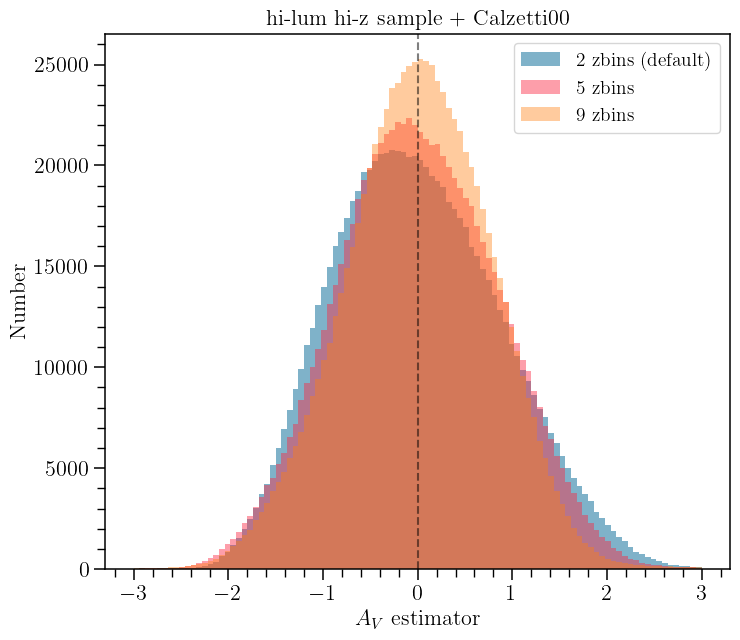

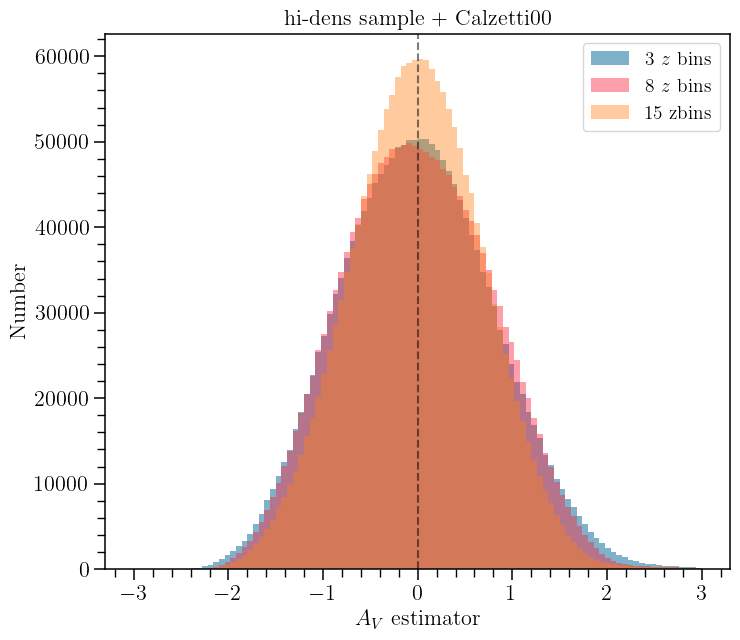

In [59]:
plt.figure(figsize=(7.5,6.5), tight_layout=True)
plt.hist(hiz_tcat['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='2 zbins (default)', alpha=0.5, color='xkcd:peacock blue')
plt.hist(hiz_tcat2['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='5 zbins', color='xkcd:strawberry', alpha=0.45)
plt.hist(hiz_tcat3['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='9 zbins', color='tab:orange', alpha=0.4)

plt.axvline(0, ls='--', color='k', alpha=0.5)
plt.xlabel(r'$A_V$ estimator')
plt.ylabel('Number')
plt.legend()
plt.title(r'hi-lum hi-z sample + Calzetti00')
#plt.savefig('hilum_hiz_Av_hist_Calzetti00.pdf')
plt.savefig('figures/hilum_hiz_Av_hist.png')

###
### Now repeat for hidens
###

plt.figure(figsize=(7.5,6.5), tight_layout=True)
plt.hist(hidens_tcat['k'], bins=100, range=[-3, 3], histtype='bar', 
        label=r'3 $z$ bins', alpha=0.5, color='xkcd:peacock blue')
plt.hist(hidens_tcat2['k'], bins=100, range=[-3, 3], histtype='bar', 
        label=r'8 $z$ bins', color='xkcd:strawberry', alpha=0.45)
plt.hist(hidens_tcat3['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='15 zbins', color='tab:orange', alpha=0.4)

plt.axvline(0, ls='--', color='k', alpha=0.5)
plt.xlabel(r'$A_V$ estimator')
plt.ylabel('Number')
plt.legend()
plt.title(r'hi-dens sample + Calzetti00')
#plt.savefig('lowz_hidens_Av_hist.pdf')
plt.savefig('figures/hidens_Av_hist.png')


In [45]:
hz_wg = np.abs(hiz_tcat['k'])<3
hz_wg2 = np.abs(hiz_tcat2['k'])<3
hz_wg3 = np.abs(hiz_tcat3['k'])<3

hiz_stats = stats.describe(hiz_tcat[hz_wg]['k'])
hiz_stats2 = stats.describe(hiz_tcat2[hz_wg2]['k'])
hiz_stats3 = stats.describe(hiz_tcat3[hz_wg3]['k'])

print('# ---------------------------')
print('# hilum_hiz 2 z bins statistics')
print('# ---------------------------')
print(f'{hiz_stats}')
print(f"median: {np.median(hiz_tcat[hz_wg]['k'])}")

print('')
print('# ---------------------------')
print('# hilum_hiz 5 z bins statistics')
print('# ---------------------------')
print(f'{hiz_stats2}')
print(f"median: {np.median(hiz_tcat2[hz_wg2]['k'])}")

print('')
print('# ---------------------------')
print('# hilum_hiz 9 z bins statistics')
print('# ---------------------------')
print(f'{hiz_stats3}')
print(f"median: {np.median(hiz_tcat3[hz_wg3]['k'])}")


### For hidens, now
hd_wg = np.abs(hidens_tcat['k'])<3
hd_wg2 = np.abs(hidens_tcat2['k'])<3
hd_wg3 = np.abs(hidens_tcat3['k'])<3

hidens_stats = stats.describe(hidens_tcat[hd_wg]['k'])
hidens_stats2 = stats.describe(hidens_tcat2[hd_wg2]['k'])
hidens_stats3 = stats.describe(hidens_tcat3[hd_wg3]['k'])

print('')
print('# ---------------------------')
print('# hidens 3 z bins statistics')
print('# ---------------------------')
print(hidens_stats)
print(f"median: {np.median(hidens_tcat[hd_wg]['k'])}")

print('')
print('# ---------------------------')
print('# hidens 8 z bins statistics')
print('# ---------------------------')
print(hidens_stats2)
print(f"median: {np.median(hidens_tcat2[hd_wg2]['k'])}")

print('')
print('# ---------------------------')
print('# hidens 17 z bins statistics')
print('# ---------------------------')
print(hidens_stats3)
print(f"median: {np.median(hidens_tcat3[hd_wg3]['k'])}")


# ---------------------------
# hilum_hiz 2 z bins statistics
# ---------------------------
DescribeResult(nobs=811705, minmax=(-2.9979400916209187, 2.9998772791631323), mean=0.0021931844052220603, variance=0.7841153463571251, skewness=0.23831177519843172, kurtosis=-0.33078724398571113)
median: -0.04687681472027461

# ---------------------------
# hilum_hiz 5 z bins statistics
# ---------------------------
DescribeResult(nobs=811846, minmax=(-2.997914106332241, 2.9998708876855606), mean=0.00631636153499879, variance=0.7120160708701482, skewness=0.05554916842391173, kurtosis=-0.24861083502017411)
median: -0.012166113802812921

# ---------------------------
# hilum_hiz 9 z bins statistics
# ---------------------------
DescribeResult(nobs=811175, minmax=(-2.9992775109040157, 2.999910978212553), mean=0.007397561034032098, variance=0.5876252860876641, skewness=-0.07309705306505544, kurtosis=0.01970708654564346)
median: 0.017425959379184584

# ---------------------------
# hidens 3 z bins st

In [ ]:
hidens_stats2.skewness

## Comparing redshift bins and dust models

In [9]:
###
### First, define some parameters
###

# Set z_theory and z_foreground levels
z_theory = 0.36 # Menard
z_fg = 0.088 # Filtered WISExSCOS

theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

scl = fg_gal_kpc.value
#theory_scl = 304*cosmo.h -- yields their answer
theory_scl = theory_kpc.value
xlabel_unit = 'kpc'
theory_r = np.logspace(-2,5,10)
av = 2.5e-3 * (theory_r/theory_scl)**(-0.86)


In [40]:
###
### Do pre-processing
###

### Hi-dens
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/redmagic_hidens_newvar/'
hidens_dk = Table.read(output_path+'dust_correlation_calzetti00_15zbins_compensated_signal.txt')
hidens_dr = Table.read(output_path+'dust_correlation_calzetti00_15zbins_bg_randoms.txt')
hidens_rr = Table.read(output_path+'dust_correlation_calzetti00_15zbins_fgxbg_randoms.txt')

### Hi-z 
output_path2 = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/redmagic_hiz/'
hiz_dk = Table.read(output_path2+'dust_correlation_calzetti00_signal.fits')
hiz_fr = Table.read(output_path2+'dust_correlation_calzetti00_fg_randoms.fits')
hiz_dr = Table.read(output_path2+'dust_correlation_calzetti00_bg_randoms.fits')
hiz_rr = Table.read(output_path2+'dust_correlation_calzetti00_fgxbg_randoms.fits')

### Now define signal 
dust_hidens = hidens_dk['kappa'] - hidens_fr['kappa'] - hidens_dr['kappa'] + hidens_rr['kappa']
dust_hidens2 = hidens2_dk['kappa'] - hidens2_fr['kappa'] - hidens2_dr['kappa'] + hidens2_rr['kappa']
dust_hidens3 = hidens3_dk['kappa'] - hidens3_fr['kappa'] - hidens3_dr['kappa'] + hidens3_rr['kappa']

dust_hiz = hiz_dk['kappa'] - hiz_fr['kappa'] - hiz_dr['kappa'] + hiz_rr['kappa']
dust_hiz2 = hiz2_dk['kappa'] - hiz2_fr['kappa'] - hiz2_dr['kappa'] + hiz2_rr['kappa']
dust_hiz3 = hiz3_dk['kappa'] - hiz3_fr['kappa'] - hiz3_dr['kappa'] + hiz3_rr['kappa']

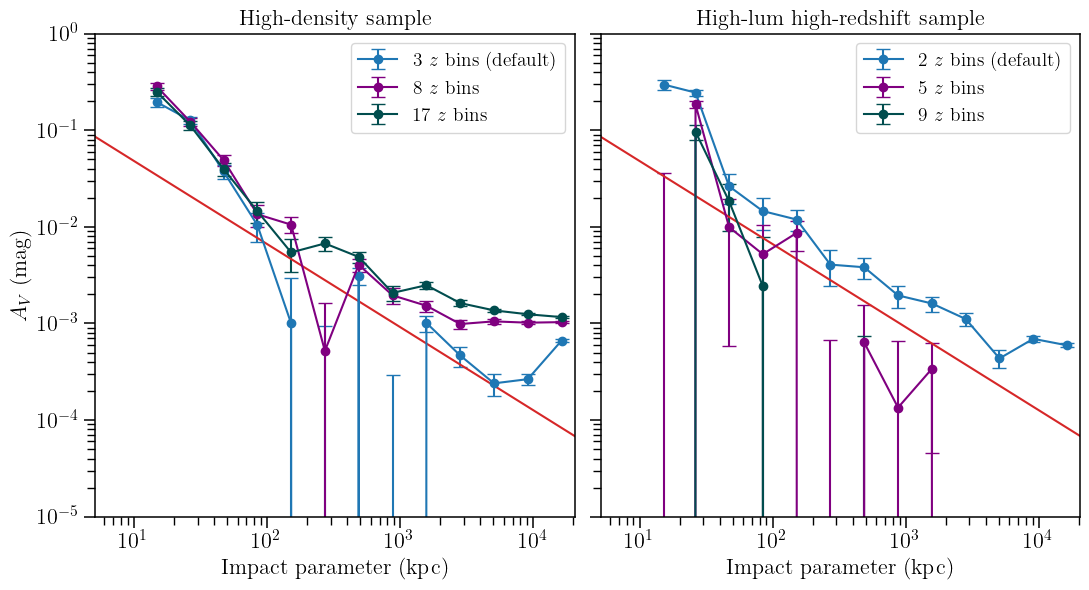

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(11,6), tight_layout=True, sharey=True)

## First do hi-dens
ax[0].errorbar(hidens_dk['meanr']*scl, dust_hidens, yerr=hidens_dk['sigma'],
            fmt='-o',capsize=5, color='tab:blue',
            label='3 $z$ bins (default)')
ax[0].errorbar(hidens2_dk['meanr']*scl, dust_hidens2, 
            yerr=hidens2_dk['sigma'], fmt='-o',capsize=5,
            color='purple', label='8 $z$ bins')
ax[0].errorbar(hidens3_dk['meanr']*scl, dust_hidens3, 
            yerr=hidens3_dk['sigma'], fmt='-o',capsize=5,
            color='xkcd:dark teal', label='17 $z$ bins')
ax[0].plot(theory_r, av, color='tab:red')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(0.05*scl, 200*scl)
ax[0].set_ylim(1E-5, 1)
ax[0].set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=16)
ax[0].set_ylabel(r'$A_V$ (mag)', fontsize=16)
ax[0].legend()
ax[0].set_title('High-density sample')


## Now do high-z part
ax[1].errorbar(hiz_dk['meanr']*scl, dust_hiz, yerr=hiz_dk['sigma'],
            fmt='-o',capsize=5, color='tab:blue',
            label='2 $z$ bins (default)')
ax[1].errorbar(hiz2_dk['meanr']*scl, dust_hiz2, 
            yerr=hiz2_dk['sigma'], fmt='-o',capsize=5,
            color='purple', label='5 $z$ bins')
ax[1].errorbar(hiz3_dk['meanr']*scl, dust_hiz3, 
            yerr=hiz3_dk['sigma'], fmt='-o',capsize=5,
            color='xkcd:dark teal', label='9 $z$ bins')

ax[1].plot(theory_r, av, color='tab:red')

ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim(0.05*scl, 200*scl)
ax[1].set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=16)
ax[1].set_title('High-lum high-redshift sample')
ax[1].legend()

fig.savefig('figures/num_redshift_bins_comparision.pdf')
fig.savefig('figures/num_redshift_bins_comparision.png')


In [19]:
###
### OK, now repeat with different dust models
### 

### Hi-dens
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/redmagic_hidens_newvar/'

hidens_dk = Table.read(
    output_path+'dust_correlation_calzetti00_15zbins_compensated_signal.txt', 
    format='ascii', header_start=1)
hidens_raw_dk = Table.read(
    output_path+'dust_correlation_calzetti00_15zbins_raw_signal.txt', 
    format='ascii', header_start=1)
hidens_fr = Table.read(
    output_path+'dust_correlation_calzetti00_15zbins_fg_randoms.txt', 
    format='ascii', header_start=1)
hidens_dr = Table.read(
    output_path+'dust_correlation_calzetti00_15zbins_bg_randoms.txt', 
    format='ascii', header_start=1)
hidens_rr = Table.read(
    output_path+'dust_correlation_calzetti00_15zbins_fgxbg_randoms.txt', 
    format='ascii', header_start=1)

fitz99_dk = Table.read(
    output_path+'dust_correlation_fitz99_15zbins_compensated_signal.txt', 
    format='ascii', header_start=1)
fitz99_dr = Table.read(output_path+'dust_correlation_fitz99_15zbins_bg_randoms.txt', 
    format='ascii', header_start=1)
fitz99_rr = Table.read(output_path+'dust_correlation_fitz99_15zbins_fgxbg_randoms.txt', 
    format='ascii', header_start=1)

ccm89_dk = Table.read(output_path+'dust_correlation_ccm89_15zbins_compensated_signal.txt', 
    format='ascii', header_start=1)
ccm89_dr = Table.read(output_path+'dust_correlation_ccm89_15zbins_bg_randoms.txt', 
    format='ascii', header_start=1)
ccm89_rr = Table.read(output_path+'dust_correlation_ccm89_15zbins_fgxbg_randoms.txt', 
    format='ascii', header_start=1)

### Now define signal 
### NOTE: It's the foreground x random correlation that is effing up my universe. 
### Don't know why. Maybe 
dust_calzetti = hidens_dk['kappa'] - hidens_dr['kappa'] + hidens_rr['kappa']
dust_fitz99 = fitz99_dk['kappa']  - fitz99_dr['kappa'] + fitz99_rr['kappa']
dust_ccm89 = ccm89_dk['kappa']  - ccm89_dr['kappa'] + ccm89_rr['kappa']


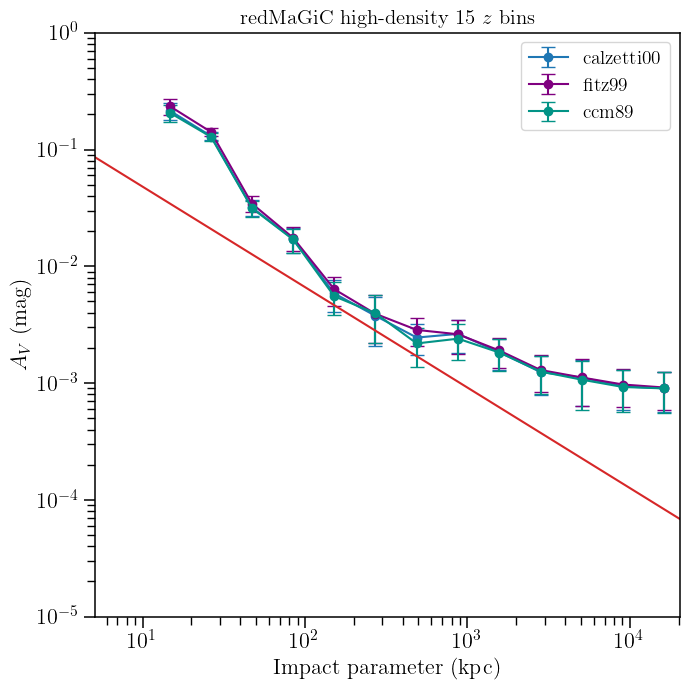

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(7,7), tight_layout=True, sharey=True)

## First do hi-dens
ax.errorbar(hidens_dk['meanr']*scl, dust_calzetti, yerr=hidens_dk['sigma'],
            fmt='-o',capsize=5, color='tab:blue',
            label='calzetti00')
ax.errorbar(fitz99_dk['meanr']*scl, dust_fitz99, 
            yerr=fitz99_dk['sigma'], fmt='-o',capsize=5,
            color='purple', label='fitz99')
ax.errorbar(ccm89_dk['meanr']*scl, dust_ccm89, 
            yerr=ccm89_dk['sigma'], fmt='-o',capsize=5,
            color='xkcd:teal', label='ccm89')
ax.plot(theory_r, av, color='tab:red')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.05*scl, 200*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=16)
ax.set_ylabel(r'$A_V$ (mag)', fontsize=16)
ax.legend()
ax.set_title('redMaGiC high-density 15 $z$ bins', fontsize=15)

fig.savefig("figures/Calzetti_vs_CCM89_vs_Fitz99.png")


#### Systematics: hiz foreground, low-z hidens background

In [ ]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos/' +\
                'output/systematics_testing/hiz_fg_hidens_bg_DIGITIZERIGHTTRUE/'
null_dk = Table.read(output_path+'dust_correlation_calzetti00_7zbins_signal.fits')
null_fr = Table.read(output_path+'dust_correlation_calzetti00_7zbins_fg_randoms.fits')
null_dr = Table.read(output_path+'dust_correlation_calzetti00_7zbins_bg_randoms.fits')
null_rr = Table.read(output_path+'dust_correlation_calzetti00_7zbins_fgxbg_randoms.fits')

### Now define signal 
dust_null = null_dk['kappa'] - null_fr['kappa'] - null_dr['kappa'] + null_rr['kappa']


In [ ]:
###
### Don't forget to redo scale!

# Set z_theory and z_foreground levels
z_theory = 0.36 # Menard
z_fg = 0.09 # Filtered WISExSCOS

theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

scl = fg_gal_kpc.value
#theory_scl = 304*cosmo.h -- yields their answer
theory_scl = theory_kpc.value
xlabel_unit = 'kpc'
theory_r = np.logspace(-2,5,10)
av = 2.5e-3 * (theory_r/theory_scl)**(-0.86)


fig, ax = plt.subplots(1, 1, figsize=(7,5), tight_layout=True, sharey=True)

## First do hi-dens
ax.errorbar(null_dk['meanr']*scl, null_dk['kappa'], yerr=null_dk['sigma'],
            fmt='--o',capsize=5, color='tab:orange',
            label='raw signal')
ax.errorbar(null_dk['meanr']*scl, null_dk['kappa'] - null_fr['kappa'], 
            yerr=null_dk['sigma'], fmt='-o',capsize=5,
            color='tab:green', label='signal - fgr only')
ax.errorbar(null_dk['meanr']*scl, dust_null, 
            yerr=null_dk['sigma'], fmt='-o',capsize=5,
            color='tab:blue', label='signal - fgr - bgr + rr')
ax.plot(theory_r, av, color='tab:red')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.05*scl, 200*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=15)
ax.set_ylabel(r'$A_V$ (mag)', fontsize=15)
ax.legend()
ax.set_title(r'hi_lum hi_z foreground $\times$ hi_dens $z<0.45$ background', fontsize=15)

fig.savefig("figures/hiz_fg_lowzhidens_bg_extinction.png")

### Try plotting foreground on vs. foreground off

#### Hi-z redo (with right=False in digitize and four bins)

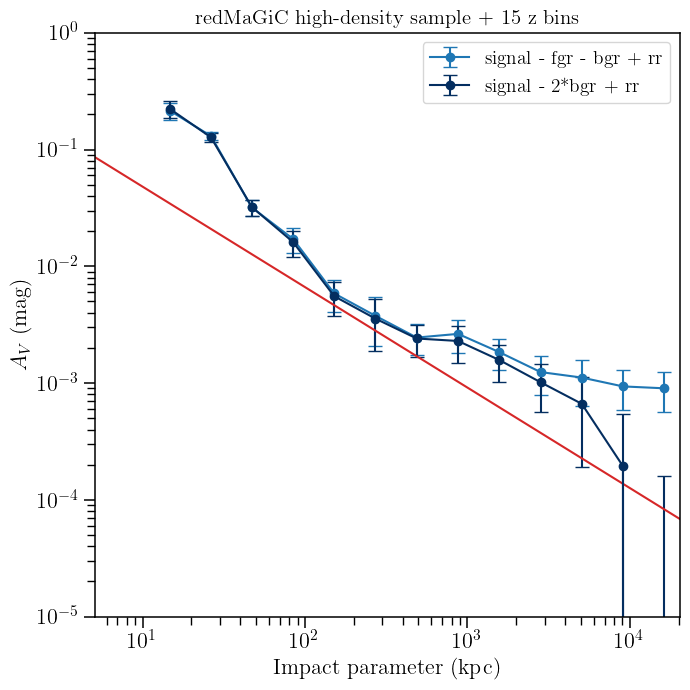

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(7,7), tight_layout=True, sharey=True)

with_fgr = hidens_raw_dk['kappa'] - \
            hidens_fr['kappa'] - hidens_dr['kappa'] + hidens_rr['kappa']
without_fgr = hidens_raw_dk['kappa'] - \
            2.0 * hidens_dr['kappa'] + hidens_rr['kappa']

## First do hi-dens
ax.errorbar(hidens_dk['meanr']*scl, with_fgr, 
            yerr=hidens_dk['sigma'], fmt='-o',capsize=5,
            color='tab:blue', label='signal - fgr - bgr + rr')
ax.errorbar(hidens_dk['meanr']*scl, without_fgr, 
            yerr=hidens_dk['sigma'], fmt='-o',capsize=5,
            color='xkcd:marine', label='signal - 2*bgr + rr')

ax.plot(theory_r, av, color='tab:red')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.05*scl, 200*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=16)
ax.set_ylabel(r'$A_V$ (mag)', fontsize=16)
ax.legend()
ax.set_title('redMaGiC high-density sample + 15 z bins', fontsize=15)
fig.savefig("figures/updated_fgr_vs_not_profile.png")


#### Hi-dens with 8 bins

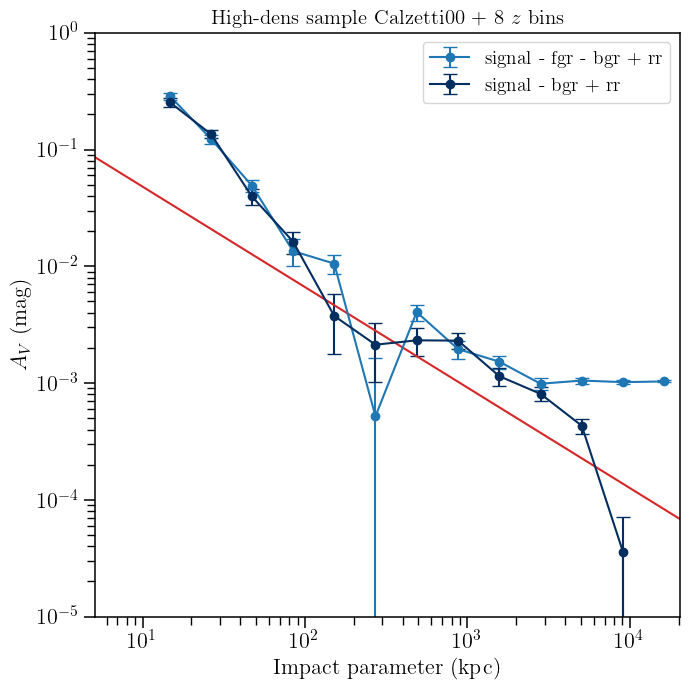

In [61]:

## dust_hidens = hidens_dk['kappa'] - hidens_fr['kappa'] 
##                   - hidens_dr['kappa'] + hidens_rr['kappa']

fig, ax = plt.subplots(1, 1, figsize=(7,7), tight_layout=True, sharey=True)

ax.errorbar(hidens2_dk['meanr']*scl, dust_hidens2, 
            yerr=hidens2_dk['sigma'], fmt='-o',capsize=5,
            color='tab:blue', label='signal - fgr - bgr + rr')
ax.errorbar(hidens2_dk['meanr']*scl, dust_hidens2 + hidens2_fr['kappa'], 
            yerr=hidens2_dk['sigma'], fmt='-o',capsize=5,
            color='xkcd:marine', label='signal - bgr + rr')

ax.plot(theory_r, av, color='tab:red')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.05*scl, 200*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=16)
ax.set_ylabel(r'$A_V$ (mag)', fontsize=16)
ax.legend()
ax.set_title('High-dens sample Calzetti00 + 8 $z$ bins', fontsize=15)
fig.savefig("figures/fgr_vs_not_profile_hidens.png")


#### hi dens sample 8 zbins

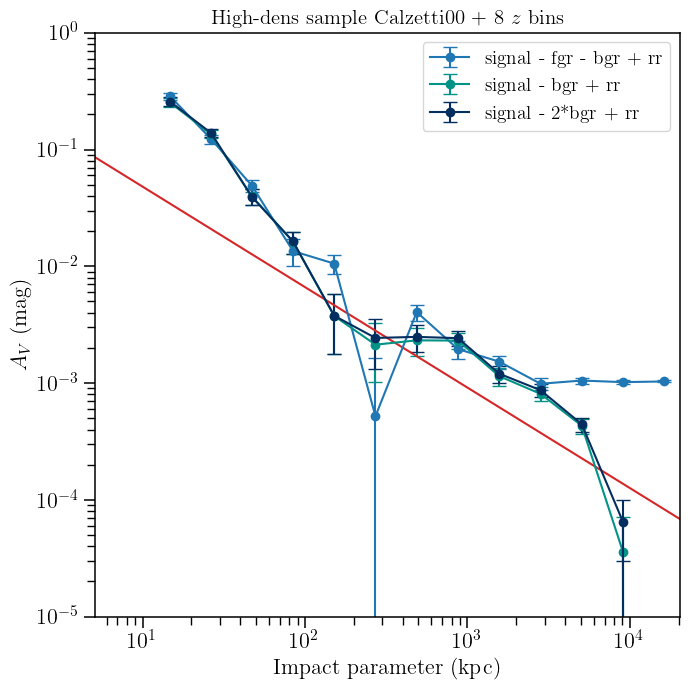

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(7,7), tight_layout=True, sharey=True)

ax.errorbar(hidens2_dk['meanr']*scl, dust_hidens2, 
            yerr=hidens2_dk['sigma'], fmt='-o',capsize=5,
            color='tab:blue', label='signal - fgr - bgr + rr')
ax.errorbar(hidens2_dk['meanr']*scl, dust_hidens2 + hidens2_fr['kappa'], 
            yerr=hidens2_dk['sigma'], fmt='-o',capsize=5,
            color='xkcd:teal', label='signal - bgr + rr')

ax.errorbar(hidens2_dk['meanr']*scl, dust_hidens2 + hidens2_fr['kappa'] \
                - hidens2_dr['kappa'], 
            yerr=hidens2_dk['sigma'], fmt='-o',capsize=5,
            color='xkcd:marine', label='signal - 2*bgr + rr')

ax.plot(theory_r, av, color='tab:red')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.05*scl, 200*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=16)
ax.set_ylabel(r'$A_V$ (mag)', fontsize=16)
ax.legend()
ax.set_title('High-dens sample Calzetti00 + 8 $z$ bins', fontsize=15)
fig.savefig("figures/fgr_vs_not_profile_hidens2.png")
